In [7]:
import torch
from pathlib import Path
from task_transfer.ml_lib.data_loading import build_dataloaders
from task_transfer.evaluation.evaluate_generative_model import evaluate_flow_model

In [8]:
model = torch.load("generative_model_mnormal.pt")
# model = torch.load("generative_model_factorized.pt")  

In [9]:
model

Joint(
  (prior): FlowDistribution(
    (base_distribution): TrainableDistributionAdapter(
      distribution_class=<class 'torch.distributions.multivariate_normal.MultivariateNormal'>, loc=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
              0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), covariance_matrix=Covariance()
      (covariance_matrix): Covariance()
    )
    (transform): SequentialTransform(
      (transforms): ModuleList(
        (0): InverseTransform(
          (transform): Softplus()
        )
        (1): IndependentAffine()
        (2): Tanh()
        (3): IndependentAffine()
        (4): Tanh()
        (5): IndependentAffine()
        (6): Tanh()
        (7): IndependentAffine()
      )
    )
  )
  (conditional): IndependentNormal(
    (trainable_distribution): IndependentTrainableDistributionAdapter(
      distribution_class=<class 'torch.distributions.normal.Normal'

In [10]:
flow = model.prior

In [11]:
flow

FlowDistribution(
  (base_distribution): TrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.multivariate_normal.MultivariateNormal'>, loc=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
            0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), covariance_matrix=Covariance()
    (covariance_matrix): Covariance()
  )
  (transform): SequentialTransform(
    (transforms): ModuleList(
      (0): InverseTransform(
        (transform): Softplus()
      )
      (1): IndependentAffine()
      (2): Tanh()
      (3): IndependentAffine()
      (4): Tanh()
      (5): IndependentAffine()
      (6): Tanh()
      (7): IndependentAffine()
    )
  )
)

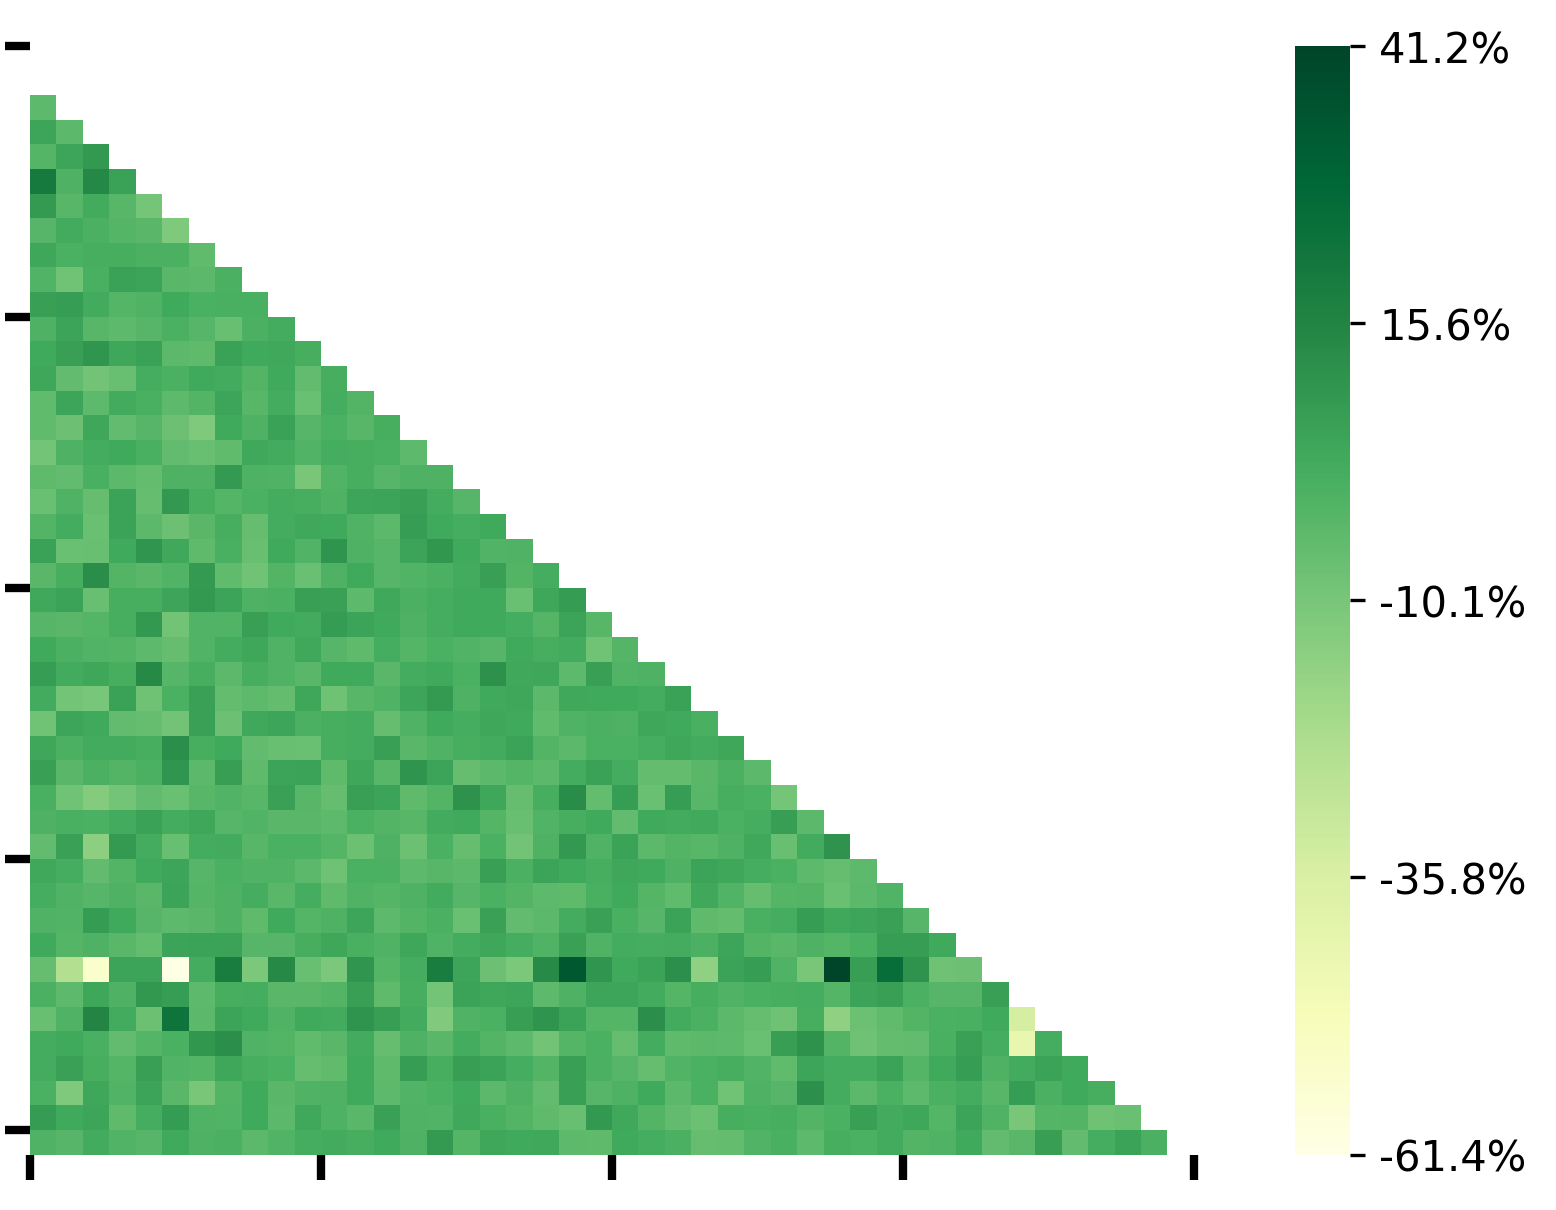

In [12]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

dpi = 300
fontsize = 16
linewidth = 4
tick_length = 6
tick_width = 2


cov = flow.base_distribution.covariance_matrix().detach()
# consider only the lower triangle without the diagonal
mask = torch.triu(torch.ones_like(cov), diagonal=-1)
antimask = torch.tril(torch.ones_like(cov), diagonal=-1)
antimasked = antimask * cov
vmin = torch.min(antimasked).item()
vmax = torch.max(antimasked).item()
cbar_ticks = np.linspace(vmin, vmax, 5)
fig_cov, ax_cov = plt.subplots(dpi=300)
sns.heatmap(
    cov.numpy(),
    mask=mask.numpy(),
    cmap="YlGn",
    vmin=vmin,
    vmax=vmax,
    ax=ax_cov,
    cbar_kws={"ticks": cbar_ticks},
)

ax_cov.set_xticks(np.arange(0, 45, 11))
ax_cov.set_yticks(np.arange(0, 45, 11))

# xticklabels = ax_cov.set_xticklabels(
#     [f"${int(np.rad2deg(x))}^\\circ$" for x in model.x_phi[::11]]
# )
# yticklabels = ax_cov.set_yticklabels(
#     [f"${int(np.rad2deg(x))}^\\circ$" for x in model.x_phi[::11]]
# )

cbar = ax_cov.collections[0].colorbar
# here set the labelsize by 20
# cbar.ax.tick_params(labelsize=fontsize)
cbar.set_ticklabels([f"{x * 100:.1f}%" for x in cbar_ticks])
ax_cov.tick_params(
    axis="both",
    which="major",
    labelsize=fontsize,
    length=tick_length,
    width=tick_width,
)

# ax_cov.set_ylabel("Preferred orientation $\\psi^x$", fontsize=fontsize)
# ax_cov.set_xlabel("Preferred orientation $\\psi^x$", fontsize=fontsize)
# ax_cov.set_title("Pearson correlation of $x$ (prior)", fontsize=fontsize)

In [13]:
n_samples = 1000000

samples = flow.sample((n_samples,))
# use at max 1000 samples to plot the histogram
n_hist_samples = min(n_samples, 10000)
# take n_hist_samples random samples from total samples
n_hist_indices = torch.randperm(n_samples)[:n_hist_samples]
hist_samples = samples[n_hist_indices]

In [14]:
hist_samples.shape

torch.Size([10000, 45])

In [15]:
data_fname = Path("/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl")

In [16]:
train_prop = 0.6
val_prop = 0.2  
test_prop = 0.2
batch_size = 128
train_loader, val_loader, test_loader = build_dataloaders(data_fname, train_prop, val_prop, batch_size)

In [17]:
all_responses = torch.cat([batch[0] for batch in val_loader], dim=0)

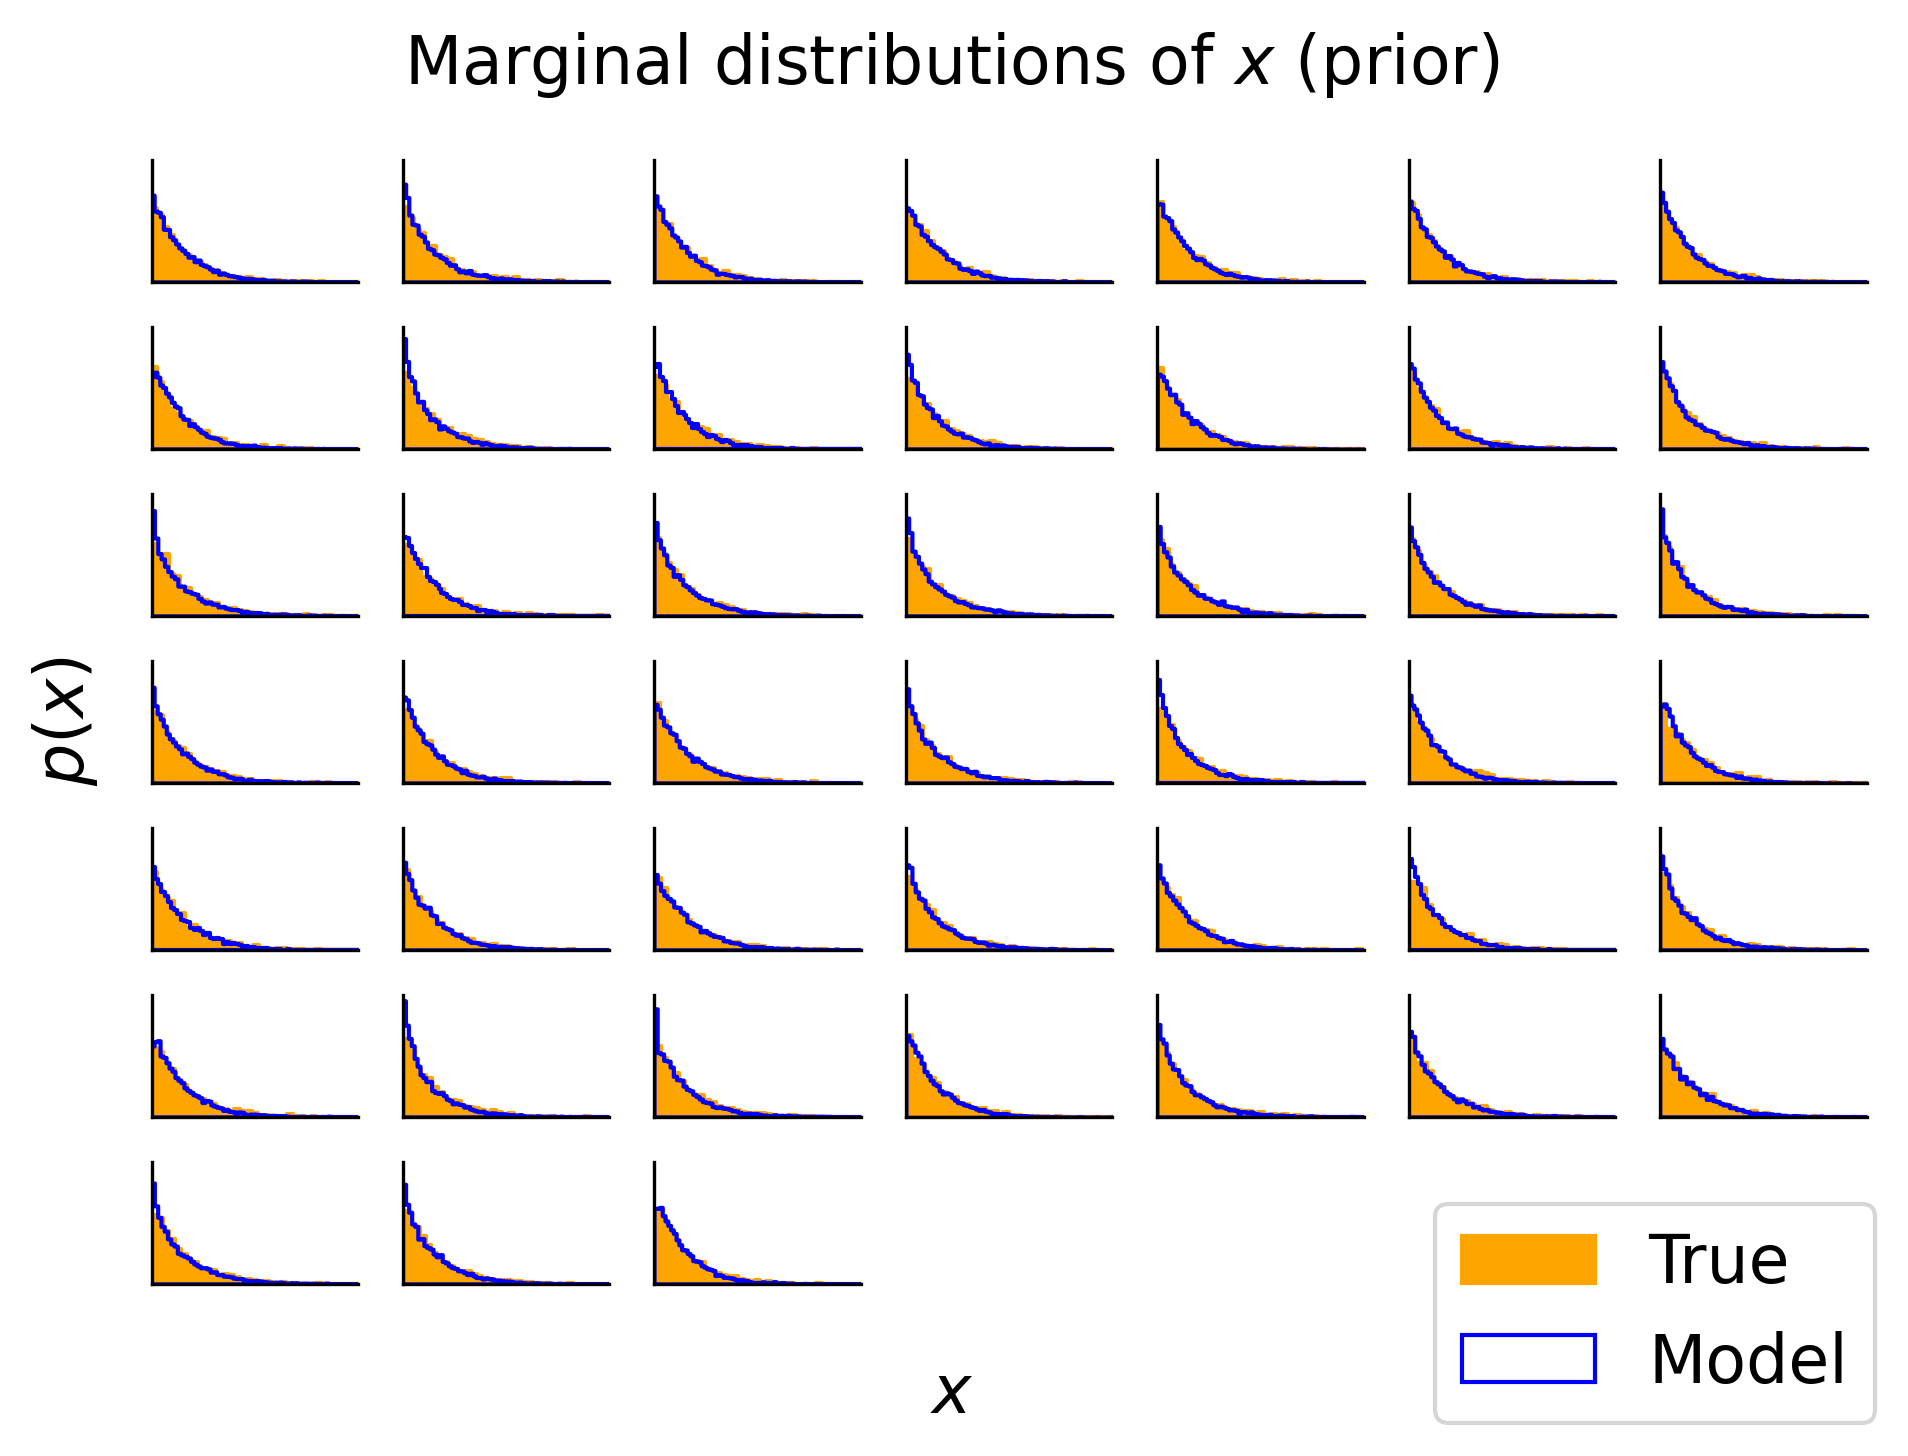

In [18]:
sample_color = "blue"
sample_alpha = 0.0
data_color = "orange"
data_alpha = 1.0
dims_to_plot = range(hist_samples.shape[1])
x_lim = (0, 7)

fig, axs = plt.subplots(
    7, 7, sharey=True, sharex=True, dpi=300
)
for idx, ax in zip(dims_to_plot, axs.flatten()):
    sns.histplot(
        all_responses[:, idx].detach().numpy(),
        ax=ax,
        stat="density",
        element="step",
        color=data_color,
        alpha=data_alpha,
        label="True",
    )
    sns.histplot(
        hist_samples[:, idx].detach().numpy(),
        ax=ax,
        stat="density",
        element="step",
        color=sample_color,
        alpha=sample_alpha,
        label="Model"
    )
    # ax.axis("off")
    ax.set_xlim(*x_lim)
    sns.despine(ax=ax)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(
        axis="both",
        which="major",
        length=0,
        width=0,
    )
fig.supxlabel("$x$", fontsize=fontsize)
fig.supylabel("$p(x)$", fontsize=fontsize)
for ax in axs.flatten()[len(dims_to_plot) :]:
    ax.axis("off")

# make legend
handles, labels = axs.flatten()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=fontsize)
fig.suptitle("Marginal distributions of $x$ (prior)", fontsize=fontsize)
fig.tight_layout()


In [19]:
samples.shape

torch.Size([1000000, 45])

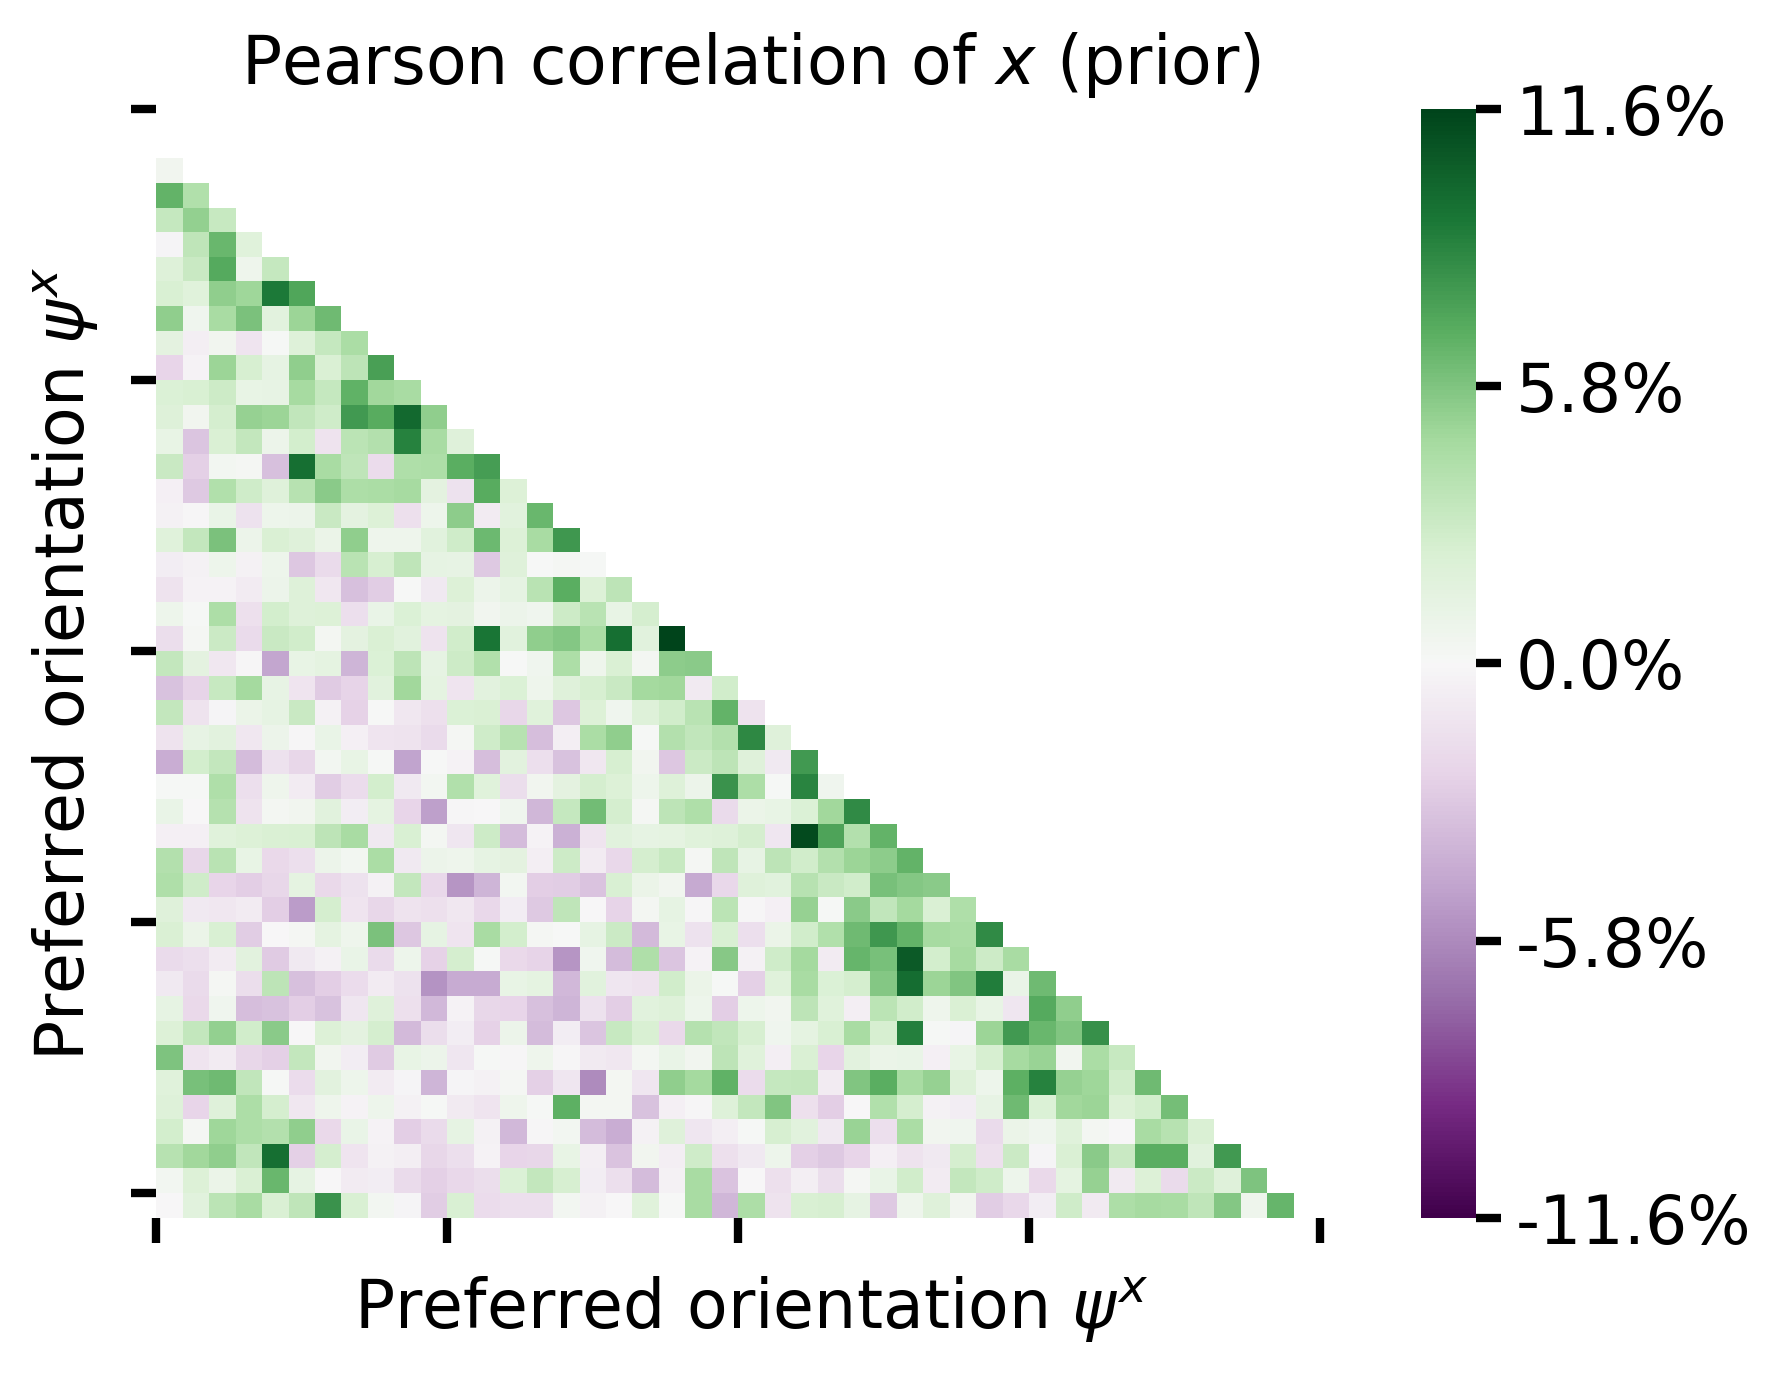

In [46]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm

# Assuming all_responses and model are already defined

xcorr_real = torch.corrcoef(all_responses.T).detach().cpu()
# consider only the lower triangle without the diagonal
mask = torch.triu(torch.ones_like(xcorr_real), diagonal=-1)
antimask = torch.tril(torch.ones_like(xcorr_real), diagonal=-1)
antimasked = antimask * xcorr_real

# Compute the max absolute value for symmetric color limits
abs_max = max(
    torch.max(torch.abs(torch.tensor([vmin, vmax]))).item(),
    torch.max(torch.abs(antimasked)).item(),
)
vmin = -abs_max
vmax = abs_max

# Define color bar ticks
cbar_ticks = np.linspace(vmin, vmax, 5)

# Plotting
fig_xcorr_real, ax_xcorr_real = plt.subplots(dpi=300)
sns.heatmap(
    xcorr_real.numpy(),
    mask=mask.numpy(),
    cmap="PRGn",
    norm=TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax),
    ax=ax_xcorr_real,
    cbar_kws={"ticks": cbar_ticks},
)

# Adjust x and y ticks
ax_xcorr_real.set_xticks(np.arange(0, 45, 11))
ax_xcorr_real.set_yticks(np.arange(0, 45, 11))

# Customize colorbar
cbar = ax_xcorr_real.collections[0].colorbar
cbar.set_ticklabels([f"{x * 100:.1f}%" for x in cbar_ticks])
cbar.ax.tick_params(labelsize=fontsize)
cbar.ax.tick_params(labelsize=fontsize, length=tick_length, width=tick_width)

# Customize axis ticks
ax_xcorr_real.tick_params(
    axis="both",
    which="major",
    labelsize=fontsize,
    length=tick_length,
    width=tick_width,
)

# Set labels and title
ax_xcorr_real.set_ylabel("Preferred orientation $\\psi^x$", fontsize=fontsize)
ax_xcorr_real.set_xlabel("Preferred orientation $\\psi^x$", fontsize=fontsize)
ax_xcorr_real.set_title("Pearson correlation of $x$ (data)", fontsize=fontsize)

plt.show()

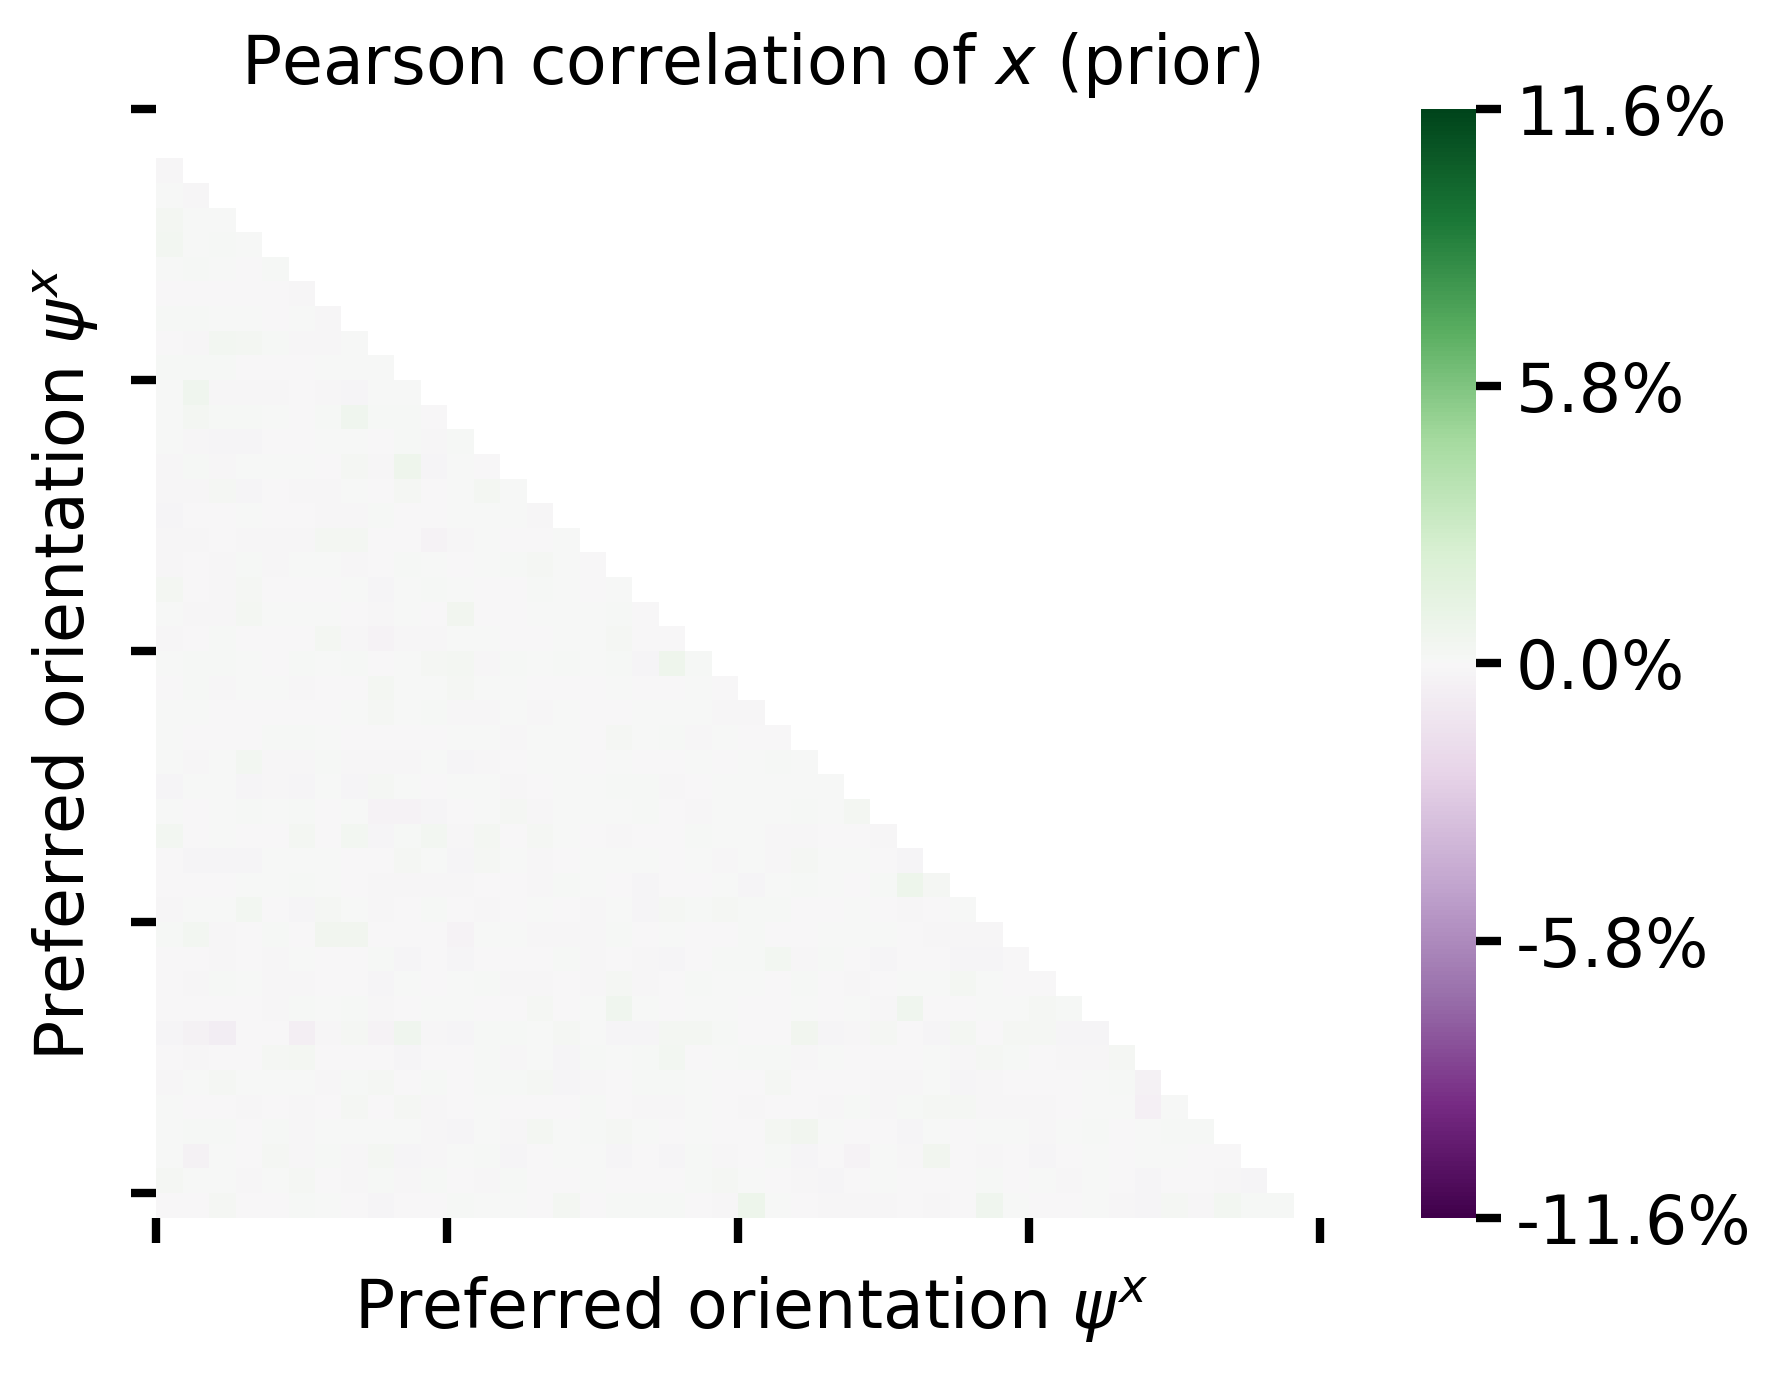

In [45]:
xcorr_sample = torch.corrcoef(samples.T).detach().cpu()

antimasked = antimask * xcorr_sample

fig_xcorr_sample, ax_xcorr_sample = plt.subplots(dpi=300)
sns.heatmap(
    xcorr_sample.numpy(),
    mask=mask.numpy(),
    cmap="PRGn",
    norm=TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax),
    ax=ax_xcorr_sample,
    cbar_kws={"ticks": cbar_ticks},
)

ax_xcorr_sample.set_xticks(np.arange(0, 45, 11))
ax_xcorr_sample.set_yticks(np.arange(0, 45, 11))
cbar = ax_xcorr_sample.collections[0].colorbar
cbar.set_ticklabels([f"{x * 100:.1f}%" for x in cbar_ticks])
cbar.ax.tick_params(labelsize=fontsize, length=tick_length, width=tick_width)

# Customize axis ticks
ax_xcorr_sample.tick_params(
    axis="both",
    which="major",
    labelsize=fontsize,
    length=tick_length,
    width=tick_width,
)

# Set labels and title
ax_xcorr_sample.set_ylabel("Preferred orientation $\\psi^x$", fontsize=fontsize)
ax_xcorr_sample.set_xlabel("Preferred orientation $\\psi^x$", fontsize=fontsize)
ax_xcorr_sample.set_title("Pearson correlation of $x$ (model)", fontsize=fontsize)

plt.show()

In [36]:
directional_similarity = torch.where(torch.sign(xcorr_real) == torch.sign(xcorr_sample), torch.ones_like(xcorr_real), torch.zeros_like(xcorr_real))

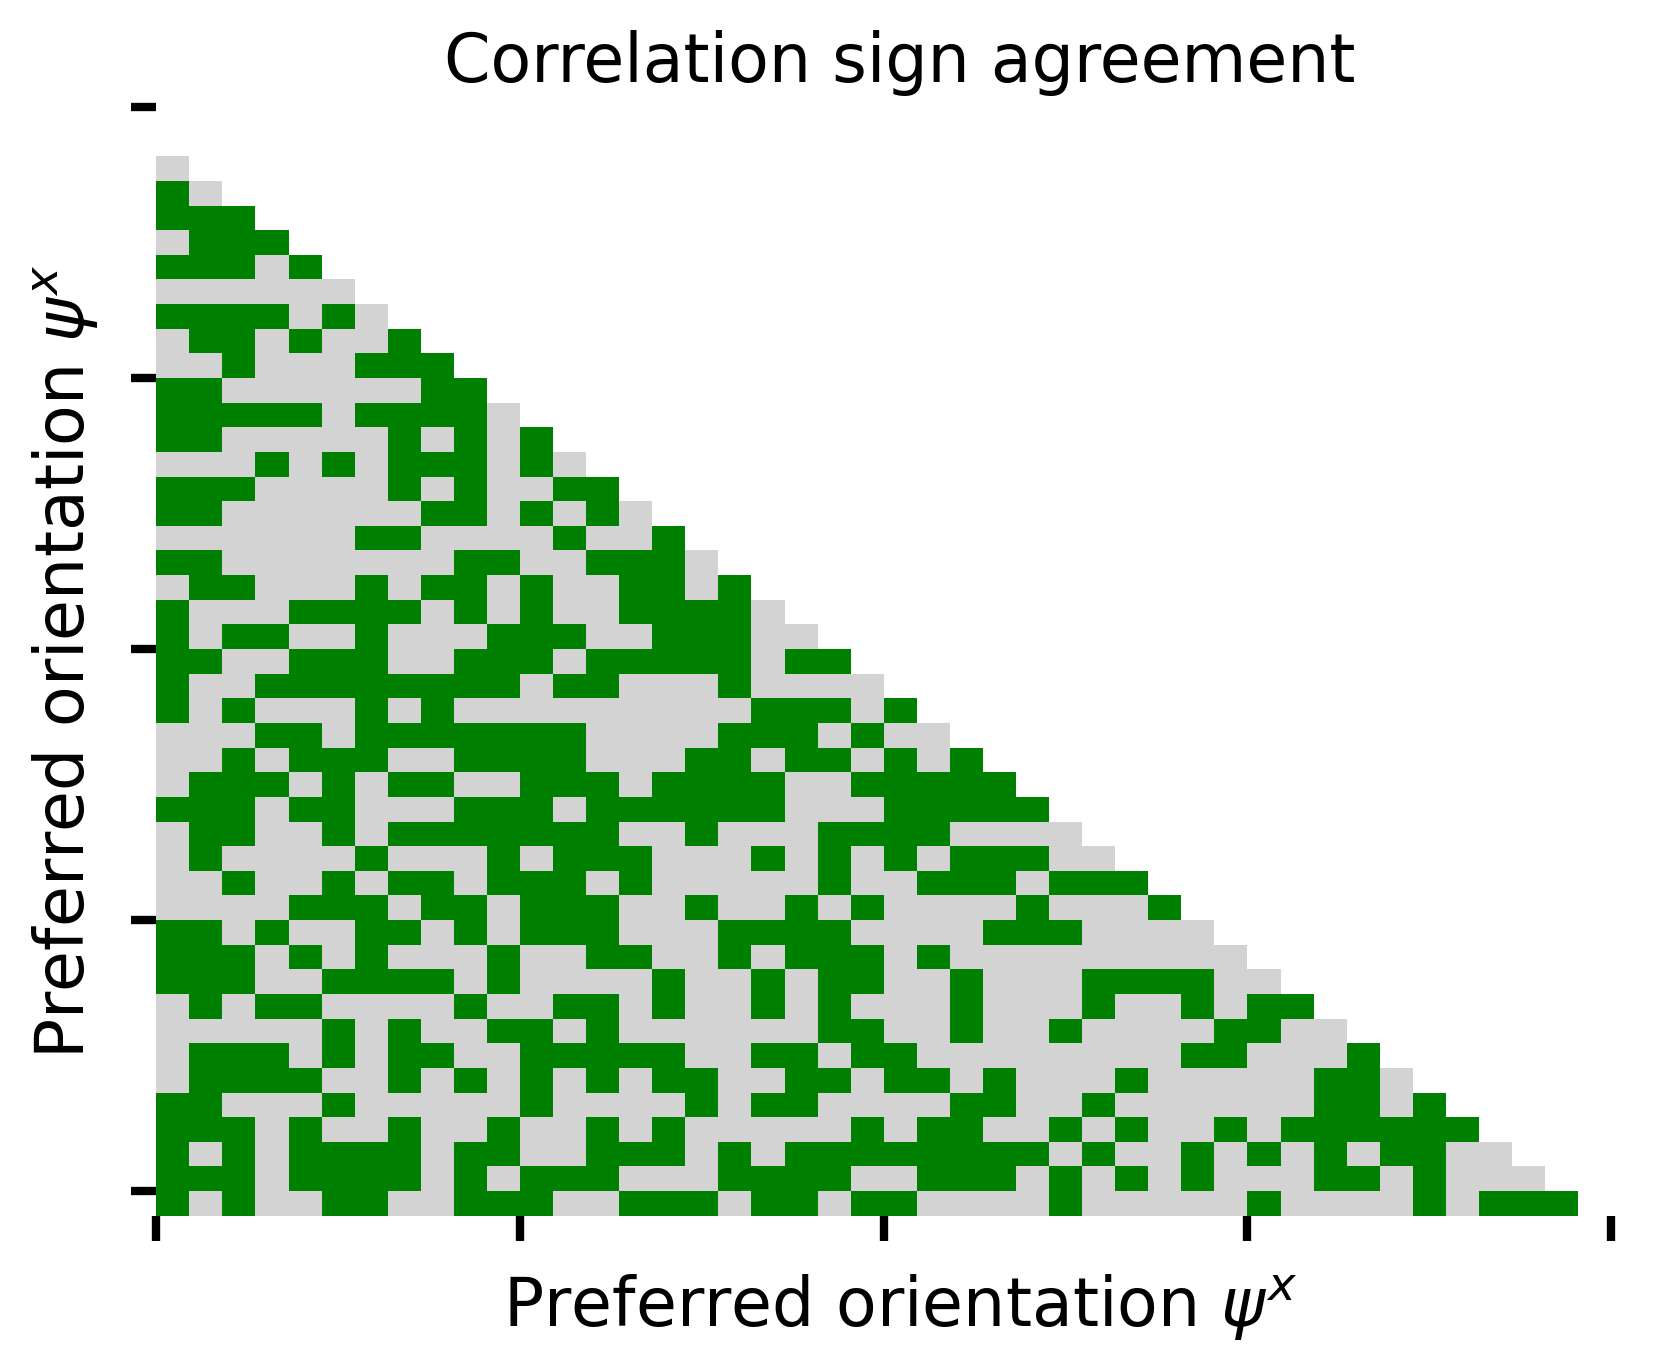

In [63]:
fig_xcorr_sgn_agr, ax_xcorr_sgn_agr = plt.subplots(dpi=300)
from matplotlib.colors import ListedColormap

# Define the colors for the colormap: dark red for 0, dark green for 1
colors = ["lightgray", "green"]

# Create the colormap
cmap = ListedColormap(colors)
sns.heatmap(
    directional_similarity.numpy(),
    mask=mask.numpy(),
    cmap=cmap,
    ax=ax_xcorr_sgn_agr,
    cbar=False
)

# Adjust x and y ticks
ax_xcorr_sgn_agr.set_xticks(np.arange(0, 45, 11))
ax_xcorr_sgn_agr.set_yticks(np.arange(0, 45, 11))

ax_xcorr_sgn_agr.tick_params(
    axis="both",
    which="major",
    labelsize=fontsize,
    length=tick_length,
    width=tick_width,
)

# Set labels and title
ax_xcorr_sgn_agr.set_ylabel("Preferred orientation $\\psi^x$", fontsize=fontsize)
ax_xcorr_sgn_agr.set_xlabel("Preferred orientation $\\psi^x$", fontsize=fontsize)
ax_xcorr_sgn_agr.set_title("Correlation sign agreement", fontsize=fontsize)
# fig_xcorr_sgn_agr.savefig(fig_save_dir / "xcorr_sgn_agr.pdf", bbox_inches="tight")

In [64]:
mask.shape

torch.Size([45, 45])

In [69]:
directional_similarity * antimask

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [1., 0., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 1., 0., 0.],
        [1., 0., 1.,  ..., 1., 0., 0.]])

In [68]:
(directional_similarity * antimask / antimask.sum()).sum()

tensor(0.4939)

[Text(-0.1, 0, '−0.10'), Text(-0.05, 0, '−0.05'), Text(0.0, 0, '0.00'), Text(0.05000000000000002, 0, '0.05'), Text(0.1, 0, '0.10'), Text(0.15, 0, '0.15')]
[-0.1  -0.05  0.    0.05  0.1   0.15]


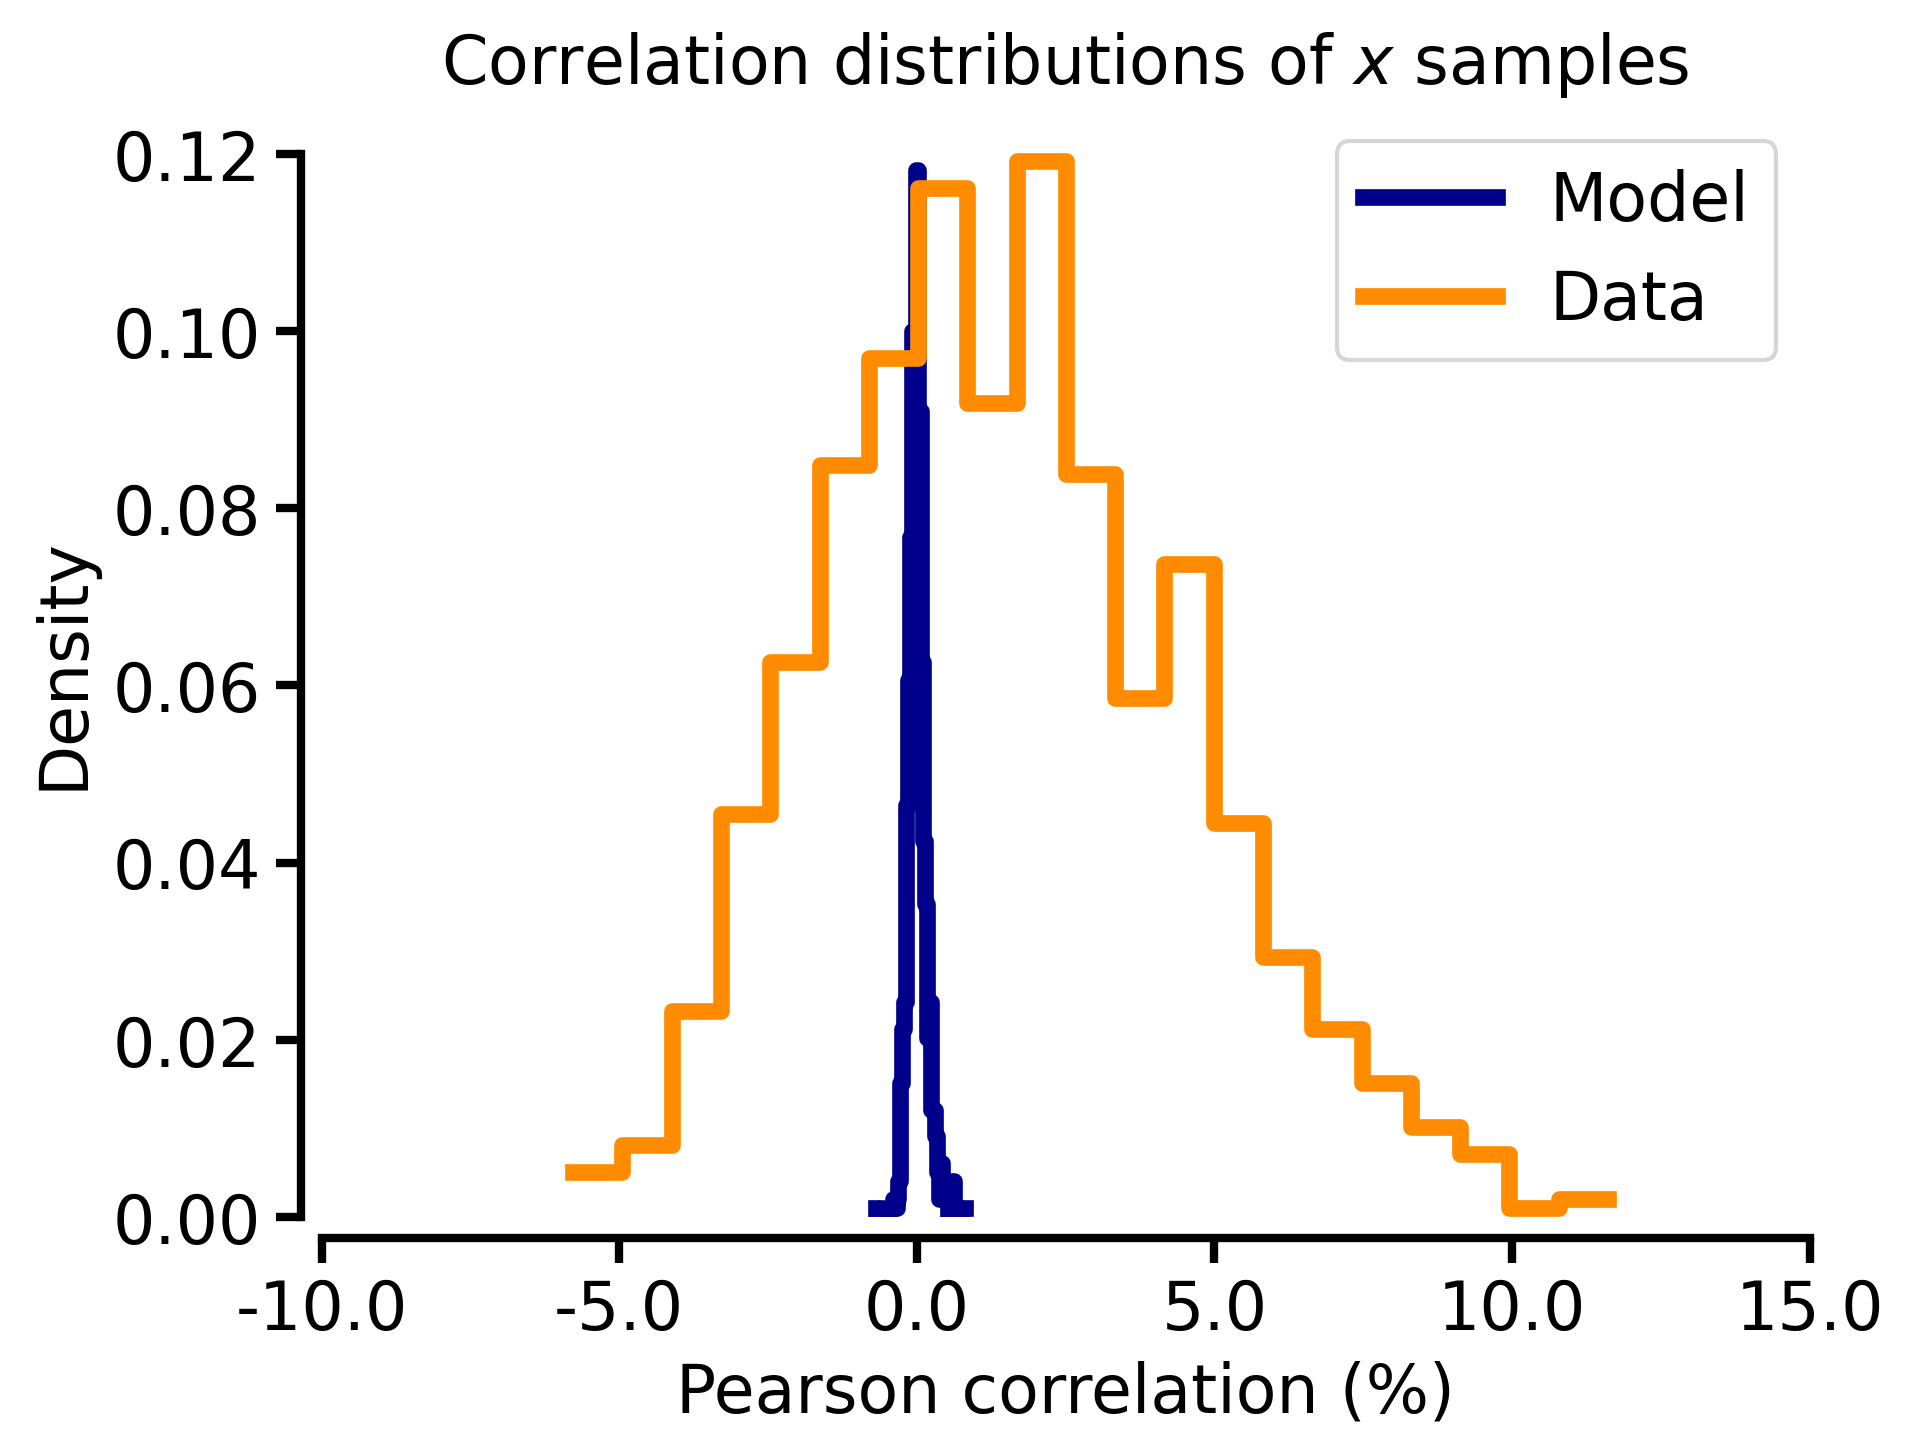

In [34]:
fig_dpi=300

fig_xcorr_hist, ax_xcorr_hist = plt.subplots(dpi=fig_dpi)

sns.histplot(
    torch.masked_select(xcorr_sample, antimask.bool()),
    ax=ax_xcorr_hist,
    stat="probability",
    element="step",
    # kde=True,
    color="darkblue",
    label="Model",
    fill=False,
    linewidth=linewidth,
)

sns.histplot(
    torch.masked_select(xcorr_real, antimask.bool()),
    ax=ax_xcorr_hist,
    stat="probability",
    element="step",
    fill=False,
    color="darkorange",
    label="Data",
    linewidth=linewidth,
)
ax_xcorr_hist.set_xlabel("Pearson correlation (%)", fontsize=fontsize)
ax_xcorr_hist.set_ylabel("Density", fontsize=fontsize)
ax_xcorr_hist.tick_params(
    axis="both",
    which="major",
    labelsize=fontsize,
    length=tick_length,
    width=tick_width,
)
ax_xcorr_hist.legend(fontsize=fontsize)
ax_xcorr_hist.set_title("Correlation distributions of $x$ samples", fontsize=fontsize)
# ax_xcorr_hist.set_xticklabels(ax_xcorr_hist.get_xticks(), fontsize=fontsize)
xtickslabels = ax_xcorr_hist.get_xticklabels()
print(ax_xcorr_hist.get_xticklabels())
print(ax_xcorr_hist.get_xticks())
ax_xcorr_hist.set_xticks(ax_xcorr_hist.get_xticks())
ax_xcorr_hist.set_xticklabels([f"{x*100:.1f}" for x in ax_xcorr_hist.get_xticks()])
sns.despine(ax=ax_xcorr_hist, trim=True, offset=5)
ax_xcorr_hist.spines[["left", "bottom"]].set_linewidth(tick_width) 
# fig_xcorr_hist.savefig(
#     fig_save_dir / "model_correlation_hist.pdf",
#     bbox_inches="tight",
#     transparent=True,
# )